# Has the euro weakened?
### EUR/USD and EUR/CHF, 1999 to today — a five-phase analysis

Data Analysis with Python · Digital Learning Hub Luxembourg

---

## The question

> **"The euro has weakened against other major currencies since it launched."**

You will hear this said as though it were simple fact. Your job is to check it.

## The data

The European Central Bank publishes the euro's exchange rate against about 40
currencies, every working day, since January 1999. It is free and needs no account.

We use two of those currencies:

- **USD** — how many US dollars one euro buys
- **CHF** — how many Swiss francs one euro buys

⚠️ **Read the direction carefully.** Both numbers say *how much one euro buys*. So
when the number goes **up**, the euro is **stronger**. Most mistakes in this project
come from reading it backwards.

## Why two currencies and not one

If the euro fell against both, the euro is weak.
If it fell against only one, the story is about that other currency.

One currency on its own cannot tell you which of those is true. That is the whole
reason there are two.

## A note on live data

The file updates every working day, so your numbers will be slightly different from
any figure written in this notebook, and different again next month. Always print the
date range you loaded and quote it with your results.


---
# Setup

Nothing to download. Run these two cells and move on.

In [ ]:
%pip install pandas matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print('pandas', pd.__version__)

pandas 2.2.3


---
# Phase 1 : Get the data and look at it

Before changing anything, find out what you have.

## 1.1 Load the file

The ECB publishes the data as a zip file. pandas can read it straight from the web —
you do not need to download or unzip anything.

```python
url = 'https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip'
```

Read it into `raw`, then print the shape and the first three rows.

In [ ]:
url = 'https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip'
raw=pd.read_csv(url)
print(raw.shape)
display(raw.head(3))

(7095, 43)


,Date,USD,JPY,BGN,CYP,CZK,DKK,EEK,GBP,HUF,...,INR,KRW,MXN,MYR,NZD,PHP,SGD,THB,ZAR,Unnamed: 42
0,2026-09-17,1.1481,178.75,NaN,NaN,24.308,7.4753,NaN,0.8583,362.98,...,110.1475,1587.31,19.7337,4.7061,1.9993,72.006,1.4642,38.237,18.6595,NaN
1,2026-09-16,1.1537,178.88,NaN,NaN,24.313,7.4755,NaN,0.8574,364.45,...,110.7140,1578.03,19.7723,4.7152,2.0021,72.370,1.4690,38.361,18.7684,NaN
2,2026-09-15,1.1539,178.86,NaN,NaN,24.292,7.4752,NaN,0.8558,366.03,...,110.7285,1568.32,19.7972,4.7160,2.0042,72.467,1.4683,38.419,18.7777,NaN


In [ ]:
display(raw.iloc[0])

,0
Date,2026-09-17
USD,1.1481
JPY,178.75
BGN,NaN
CYP,NaN
CZK,24.308
DKK,7.4753
EEK,NaN
GBP,0.8583
HUF,362.98


In [ ]:
display(raw.tail())

,Date,USD,JPY,BGN,CYP,CZK,DKK,EEK,GBP,HUF,...,INR,KRW,MXN,MYR,NZD,PHP,SGD,THB,ZAR,Unnamed: 42
7090,1999-01-08,1.1659,130.09,NaN,0.58187,34.938,7.4433,15.6466,0.70940,250.15,...,NaN,1366.73,NaN,NaN,2.1557,NaN,1.9537,NaN,6.7855,NaN
7091,1999-01-07,1.1632,129.43,NaN,0.58187,34.886,7.4431,15.6466,0.70585,250.09,...,NaN,1337.16,NaN,NaN,2.1531,NaN,1.9436,NaN,6.8283,NaN
7092,1999-01-06,1.1743,131.42,NaN,0.58200,34.850,7.4452,15.6466,0.70760,250.67,...,NaN,1359.54,NaN,NaN,2.1890,NaN,1.9699,NaN,6.7307,NaN
7093,1999-01-05,1.1790,130.96,NaN,0.58230,34.917,7.4495,15.6466,0.71220,250.80,...,NaN,1373.01,NaN,NaN,2.2011,NaN,1.9655,NaN,6.7975,NaN
7094,1999-01-04,1.1789,133.73,NaN,0.58231,35.107,7.4501,15.6466,0.71110,251.48,...,NaN,1398.59,NaN,NaN,2.2229,NaN,1.9554,NaN,6.9358,NaN


## 1.2 Keep only what you need

The file has about 40 currency columns. You need three: `Date`, `USD` and `CHF`.

Make a new DataFrame called `df` with just those three columns, and show the first
few rows.

In [ ]:
display(raw.head())

,Date,USD,JPY,BGN,CYP,CZK,DKK,EEK,GBP,HUF,...,INR,KRW,MXN,MYR,NZD,PHP,SGD,THB,ZAR,Unnamed: 42
0,2026-09-17,1.1481,178.75,NaN,NaN,24.308,7.4753,NaN,0.85830,362.98,...,110.1475,1587.31,19.7337,4.7061,1.9993,72.006,1.4642,38.237,18.6595,NaN
1,2026-09-16,1.1537,178.88,NaN,NaN,24.313,7.4755,NaN,0.85740,364.45,...,110.7140,1578.03,19.7723,4.7152,2.0021,72.370,1.4690,38.361,18.7684,NaN
2,2026-09-15,1.1539,178.86,NaN,NaN,24.292,7.4752,NaN,0.85580,366.03,...,110.7285,1568.32,19.7972,4.7160,2.0042,72.467,1.4683,38.419,18.7777,NaN
3,2026-09-14,1.1551,178.52,NaN,NaN,24.294,7.4753,NaN,0.85598,365.33,...,110.3755,1555.04,19.7200,4.7082,2.0012,72.619,1.4676,38.407,18.7695,NaN
4,2026-09-11,1.1592,178.56,NaN,NaN,24.264,7.4748,NaN,0.85815,364.45,...,110.7675,1556.56,19.6798,4.7185,1.9914,72.600,1.4697,38.329,18.7312,NaN


In [ ]:
display(raw.iloc[-1]) #the last raw

,7094
Date,1999-01-04
USD,1.1789
JPY,133.73
BGN,NaN
CYP,0.58231
CZK,35.107
DKK,7.4501
EEK,15.6466
GBP,0.7111
HUF,251.48


In [ ]:
# Your code here
df=raw[['Date','USD','CHF']]
display(df.head())

,Date,USD,CHF
0,2026-09-17,1.1481,0.9466
1,2026-09-16,1.1537,0.9449
2,2026-09-15,1.1539,0.9441
3,2026-09-14,1.1551,0.9431
4,2026-09-11,1.1592,0.9451


In [ ]:
print(df["USD"].min())
print(df["USD"].max())

0.8252
1.599


In [ ]:
print(df["CHF"].min())
print(df["CHF"].max())

0.9008
1.6803


## 1.3 What type is each column?

Use `.info()` on `df`.

One column is not the type you would expect. Which one, and why does that matter?

In [ ]:
# Your code here
df.info()
colums=df.columns
colums

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7095 entries, 0 to 7094
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    7095 non-null   object 
 1   USD     7095 non-null   float64
 2   CHF     7095 non-null   float64
dtypes: float64(2), object(1)
memory usage: 166.4+ KB


Index(['Date', 'USD', 'CHF'], dtype='object')

## 1.4 How much data is there?

Print the first and last date in the file, and the number of rows.

Then work out roughly how many rows there are per year. It will not be 365 —
explain why in a comment.

In [ ]:
# Your code here
print("First date:", df["Date"].iloc[0])
print("last date:", df["Date"].iloc[-1])
print("rows:", len(df))
years = len(df)/253

#52 weeks * 2 weekend days= 104 per year
# 8 holiday days in Europe
# 104 + 8 = 112 ## total days = 365 -112
print("We have arund :" , round(years), "years of date")


First date: 2026-09-17
last date: 1999-01-04
rows: 7095
We have arund : 28 years of date


---
# Phase 2 : Clean it

Three things to fix. After each one, check the result.

## 2.1 Turn Date into a real date

Convert the `Date` column with `pd.to_datetime()`, then check the type again.

In [ ]:
# Your code here
df2 = df.copy()
df2["Date"] = pd.to_datetime(df2["Date"])
print(df2.dtypes)
display(df2.head())

Date    datetime64[ns]
USD            float64
CHF            float64
dtype: object


,Date,USD,CHF
0,2026-09-17,1.1481,0.9466
1,2026-09-16,1.1537,0.9449
2,2026-09-15,1.1539,0.9441
3,2026-09-14,1.1551,0.9431
4,2026-09-11,1.1592,0.9451


## 2.2 Put it in date order

The ECB publishes the newest row first. Sort `df` so the oldest date comes first,
then print the first and last rows.

Why does this matter? Think about what happens when you calculate "today minus
yesterday" on a table that runs backwards.

In [ ]:
# Your code here
df2 = df2.sort_values(by="Date")
display(df2.head(2))
display(df2.tail(2))

,Date,USD,CHF
7094,1999-01-04,1.1789,1.6168
7093,1999-01-05,1.1790,1.6123


,Date,USD,CHF
1,2026-09-16,1.1537,0.9449
0,2026-09-17,1.1481,0.9466


## 2.3 Check for missing values

Count the missing values in each column.

The ECB stops publishing a currency when it no longer exists, or when it can no
longer set a fair rate — the Russian rouble stopped in March 2022, for example. Are
either of our two currencies affected?

In [ ]:
# Your code here
print(df2.isna().sum())

Date    0
USD     0
CHF     0
dtype: int64


## 2.4 Does the data look sensible?

Use `.describe()` on `df`.

Look at the smallest and largest value of each currency. Do they look like real
exchange rates? What would tell you something had gone wrong?

In [ ]:
# Your code here
display(df2.describe())

,Date,USD,CHF
count,7095,7095.000000,7095.000000
mean,2012-11-07 18:29:59.238900736,1.181792,1.282485
min,1999-01-04 00:00:00,0.825200,0.900800
25%,2005-12-01 12:00:00,1.086150,1.079150
50%,2012-11-02 00:00:00,1.167800,1.219400
75%,2019-10-14 12:00:00,1.294700,1.534900
max,2026-09-17 00:00:00,1.599000,1.680300
std,NaN,0.151151,0.240214


---
# Phase 3 : Explore

Now ask the data some questions.

## 3.1 Add a year column

Add a column called `year`, taken from the date with `.dt.year`.

Then count how many rows there are per year with `value_counts()`.

In [ ]:
# Your code here
df3 = df2.copy()
df3["year"] = df3["Date"].dt.year

print(df3["year"].value_counts().sort_index())
display(df3)

year
1999    259
2000    255
2001    254
2002    255
2003    255
2004    259
2005    257
2006    255
2007    255
2008    256
2009    256
2010    258
2011    257
2012    256
2013    255
2014    255
2015    256
2016    257
2017    255
2018    255
2019    255
2020    257
2021    258
2022    257
2023    255
2024    256
2025    255
2026    182
Name: count, dtype: int64


,Date,USD,CHF,year
7094,1999-01-04,1.1789,1.6168,1999
7093,1999-01-05,1.1790,1.6123,1999
7092,1999-01-06,1.1743,1.6116,1999
7091,1999-01-07,1.1632,1.6165,1999
7090,1999-01-08,1.1659,1.6138,1999
...,...,...,...,...
4,2026-09-11,1.1592,0.9451,2026
3,2026-09-14,1.1551,0.9431,2026
2,2026-09-15,1.1539,0.9441,2026
1,2026-09-16,1.1537,0.9449,2026


## 3.2 The average rate each year

Group by `year` and calculate the average of `USD` and `CHF`.

Print the first five and last five years. What do you notice about the two
currencies?

In [ ]:
# Your code here
avg_rate = df3.groupby("year")[["USD", "CHF"]].mean().round(4)
#display head and tail for d3
display(avg_rate.head())
display(avg_rate.tail())

,USD,CHF
year,,
1999,1.0658,1.6003
2000,0.9236,1.5579
2001,0.8956,1.5105
2002,0.9456,1.4670
2003,1.1312,1.5212


,USD,CHF
year,,
2022,1.0530,1.0047
2023,1.0813,0.9718
2024,1.0824,0.9526
2025,1.1300,0.9370
2026,1.1620,0.9227


## 3.3 Daily changes

Add two columns, `usd_change` and `chf_change`, holding the daily percentage change
of each rate. Use `.pct_change() * 100`.

Then print `.describe()` for those two columns.

In [ ]:
# Your code here
df3["usd_change"] = df3["USD"].pct_change() * 100
df3["chf_change"] = df3["CHF"].pct_change() * 100
print(df3[["usd_change", "chf_change"]].describe().round(3))
display(df3)

       usd_change  chf_change
count    7094.000    7094.000
mean        0.001      -0.007
std         0.581       0.392
min        -4.625     -14.405
25%        -0.314      -0.146
50%         0.000       0.000
75%         0.315       0.140
max         4.294       8.325


,Date,USD,CHF,year,usd_change,chf_change
7094,1999-01-04,1.1789,1.6168,1999,NaN,NaN
7093,1999-01-05,1.1790,1.6123,1999,0.008482,-0.278328
7092,1999-01-06,1.1743,1.6116,1999,-0.398643,-0.043416
7091,1999-01-07,1.1632,1.6165,1999,-0.945244,0.304046
7090,1999-01-08,1.1659,1.6138,1999,0.232118,-0.167028
...,...,...,...,...,...,...
4,2026-09-11,1.1592,0.9451,2026,-0.206612,0.201442
3,2026-09-14,1.1551,0.9431,2026,-0.353692,-0.211618
2,2026-09-15,1.1539,0.9441,2026,-0.103887,0.106033
1,2026-09-16,1.1537,0.9449,2026,-0.017333,0.084737


## 3.4 The biggest single day

Find the five largest daily changes for each currency, together with their dates.

Hint: sort the DataFrame by the change column and look at the top and bottom.

One of them is far bigger than all the others. Find out what happened on that day.

In [ ]:
# Your code here
lowest_usd = df3.sort_values("usd_change").head()
#display(lowest_usd[["Date", "USD", "usd_change"]])
biggest_usd = df3.sort_values("usd_change").tail()
biggest_chf = df3.sort_values("chf_change").head()
display(biggest_usd[["Date", "USD", "usd_change"]])
display(biggest_chf[["Date", "CHF", "chf_change"]])

,Date,USD,usd_change
982,2022-11-11,1.0308,3.556359
4542,2008-12-18,1.4616,3.961875
4480,2009-03-19,1.3671,4.120335
6649,2000-09-22,0.8890,4.293759
7094,1999-01-04,1.1789,NaN


,Date,CHF,chf_change
2988,2015-01-15,1.0280,-14.404663
3887,2011-07-11,1.1715,-3.197819
1088,2022-06-16,1.0142,-2.807858
3848,2011-09-02,1.1132,-2.496277
4581,2008-10-24,1.4566,-2.424973


## 3.5 How much does each currency move?

Use `.std()` on the two change columns to see which currency moves more from day to
day.

Then group by `year` and calculate the standard deviation of `chf_change` for each
year. Look at 2012, 2013 and 2014, then at 2015. What do you see?

In [ ]:
# Your code here

change_by_year = df3[['usd_change', 'chf_change']].std().round(3)
print(change_by_year)
display(df3.groupby('year')['chf_change'].std().round(3))

display(df3.groupby('year')['usd_change'].std().round(3))

usd_change    0.581
chf_change    0.392
dtype: float64


,chf_change
year,
1999,0.161
2000,0.277
2001,0.287
2002,0.187
2003,0.243
2004,0.206
2005,0.170
2006,0.181
2007,0.248


,usd_change
year,
1999,0.582
2000,0.867
2001,0.701
2002,0.606
2003,0.649
2004,0.598
2005,0.544
2006,0.495
2007,0.397


---
# Phase 4 : Answer the question

> **"The euro has weakened against other major currencies since it launched."**

## 4.1 From the first day to the last

Take the first and last row of `df`, and work out the percentage change in each
currency between them.

On this evidence alone, does the claim hold?

In [ ]:
# Your code here
df4= df3.copy()
first = df4.iloc[0]
last = df4.iloc[-1]
usd_change = (last["USD"] - first["USD"]) / first["USD"] * 100
chf_change = (last["CHF"] - first["CHF"]) / first["CHF"] * 100
print("USD:", round(first["USD"], 2), "->", round(last["USD"], 2), "=", round(usd_change, 2), "%")
print("CHF:", round(first["CHF"], 2), "->", round(last["CHF"], 2), "=", round(chf_change, 2), "%")

USD: 1.18 -> 1.15 = -2.61 %
CHF: 1.62 -> 0.95 = -41.45 %


## 4.2 Does the answer change if you start somewhere else?

This is the important task.

For each year, find the first rate of that year, and work out the percentage change
from there to the last rate in the file. Do it for both currencies.

Build a small table with one row per starting year, then look down the two columns.

In [ ]:
# Your code here

# First exchange rate of each year
first_by_year = df4.groupby("year")[["USD", "CHF"]].first()

# Last exchange rates in the whole dataset
last_usd = df4["USD"].iloc[-1]
last_chf = df4["CHF"].iloc[-1]

# Percentage change from each starting year to the last date
start_years = first_by_year.copy()

start_years["usd_change"] = (
    (last_usd - start_years["USD"]) / start_years["USD"] * 100
)

start_years["chf_change"] = (
    (last_chf - start_years["CHF"]) / start_years["CHF"] * 100
)

# Keep only the columns needed for the report
change_table = start_years[["usd_change", "chf_change"]].round(2)

display(change_table)


,usd_change,chf_change
year,,
1999,-2.61,-41.45
2000,13.79,-41.00
2001,21.84,-37.80
2002,27.03,-36.18
2003,9.91,-34.84
2004,-8.82,-39.38
2005,-15.00,-38.71
2006,-2.92,-39.07
2007,-13.48,-41.22


In [ ]:
report_years = [1999, 2001, 2005, 2010, 2015, 2020, 2023, 2025]

report_table = change_table.loc[report_years]

display(report_table)


,usd_change,chf_change
year,,
1999,-2.61,-41.45
2001,21.84,-37.80
2005,-15.00,-38.71
2010,-20.21,-36.35
2015,-4.67,-21.26
2020,2.57,-12.88
2023,7.47,-4.12
2025,11.24,1.01


## 4.3 Count the rises and the falls

From your table, count how many starting years give a **fall** in each currency, and
how many give a **rise**.

Write what this tells you in a comment.

In [ ]:
# Your code here
usd_falls = (df4["usd_change"] < 0).sum()
usd_raises = (df4["usd_change"] > 0).sum()
print("USD falls:", usd_falls)
print("USD raises:", usd_raises)
chf_falls = (df4["chf_change"] < 0).sum()
chf_raises = (df4["chf_change"] > 0).sum()
print("CHF falls:", chf_falls)
print("CHF raises:", chf_raises)

USD falls: 3516
USD raises: 3523
CHF falls: 3507
CHF raises: 3435


## 4.4 Comparing the two fairly

You cannot compare 1.08 dollars with 0.93 francs — they are different currencies.

To compare them, divide every value by the first value and multiply by 100. Both
currencies then start at 100, and the line shows how much has changed since then.

Add two columns, `usd_index` and `chf_index`, then print the yearly average of each
for the first and last five years.

In [ ]:
# Your code here
# Count starting years
n_years = len(change_table)

# Count falls and rises
usd_falls = (change_table["usd_change"] < 0).sum()
usd_rises = (change_table["usd_change"] > 0).sum()

chf_falls = (change_table["chf_change"] < 0).sum()
chf_rises = (change_table["chf_change"] > 0).sum()

print("Starting years:", n_years)
print("USD falls:", usd_falls)
print("USD rises:", usd_rises)
print("CHF falls:", chf_falls)
print("CHF rises:", chf_rises)

Starting years: 28
USD falls: 16
USD rises: 12
CHF falls: 25
CHF rises: 3


## 4.5 Do the two currencies move together?

Use `.corr()` on the two daily change columns.

A value near 1 would mean they always move together. A value near 0 would mean they
move independently. What did you get, and what does it mean for the question?

In [ ]:
# Your code here
# Index both currencies to 100
df4["usd_index"] = df4["USD"] / df4["USD"].iloc[0] * 100
df4["chf_index"] = df4["CHF"] / df4["CHF"].iloc[0] * 100

# Yearly average
yearly_index = df4.groupby("year")[["usd_index", "chf_index"]].mean().round(2)

print("First five years:")
display(yearly_index.head())

print("Last five years:")
display(yearly_index.tail())

First five years:


,usd_index,chf_index
year,,
1999,90.40,98.98
2000,78.35,96.35
2001,75.97,93.43
2002,80.21,90.74
2003,95.95,94.09


Last five years:


,usd_index,chf_index
year,,
2022,89.32,62.14
2023,91.72,60.11
2024,91.81,58.92
2025,95.85,57.96
2026,98.57,57.07


## 4.6 Your verdict

Write your answer as a comment. Cover three things:

1. Does the claim hold for EUR/CHF?
2. Does it hold for EUR/USD?
3. What would you say to someone who states "the euro has weakened" with no further
   detail?

In [ ]:
# Your code here
correlation = df4["usd_change"].corr(df4["chf_change"])

print("Correlation:", round(correlation, 3))

Correlation: 0.193


---
# Phase 5 : Charts and export

Six charts. Each needs a title, labels on both axes, and one sentence underneath
saying what it shows.

## 5.1 The two rates over time

Plot both currencies over time. Use `plt.subplots(2, 1)` so each gets its own panel.

Why two panels instead of both lines on one chart?

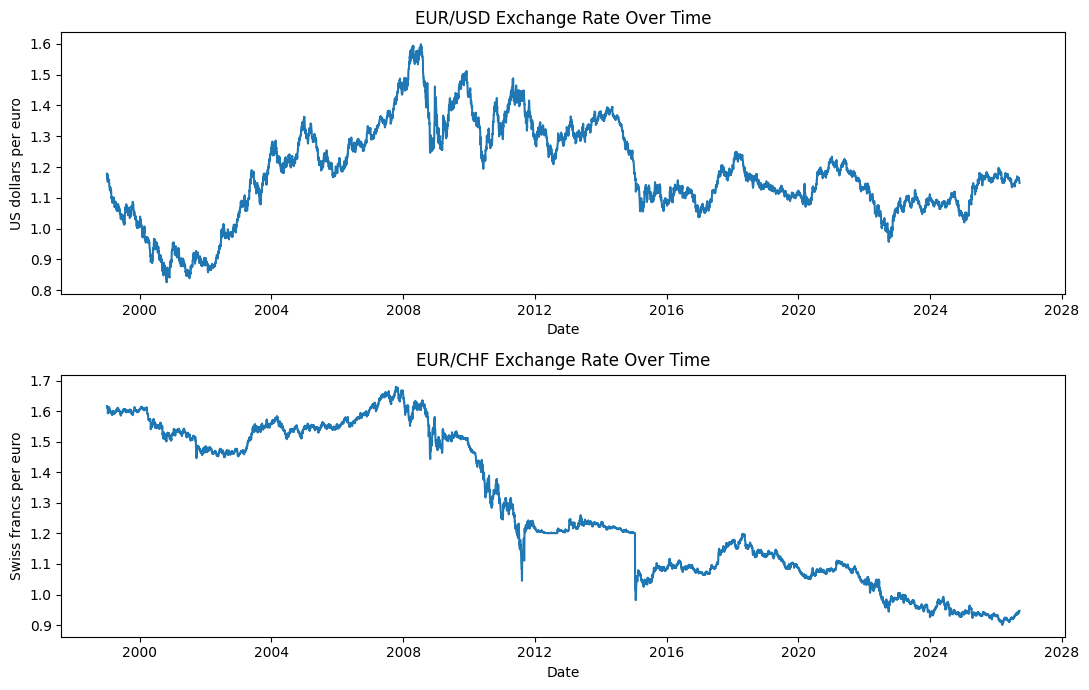

In [ ]:
# Your code here
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# EUR/USD
axes[0].plot(df4["Date"], df4["USD"])
axes[0].set_title("EUR/USD Exchange Rate Over Time")
axes[0].set_ylabel("US dollars per euro")
axes[0].set_xlabel("Date")

# EUR/CHF
axes[1].plot(df4["Date"], df4["CHF"])
axes[1].set_title("EUR/CHF Exchange Rate Over Time")
axes[1].set_ylabel("Swiss francs per euro")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 5.2 The comparison chart

Plot `usd_index` and `chf_index` on one chart, with a legend. Add a horizontal line at 100 using `plt.axhline(100)`.

This is the chart that answers the question.

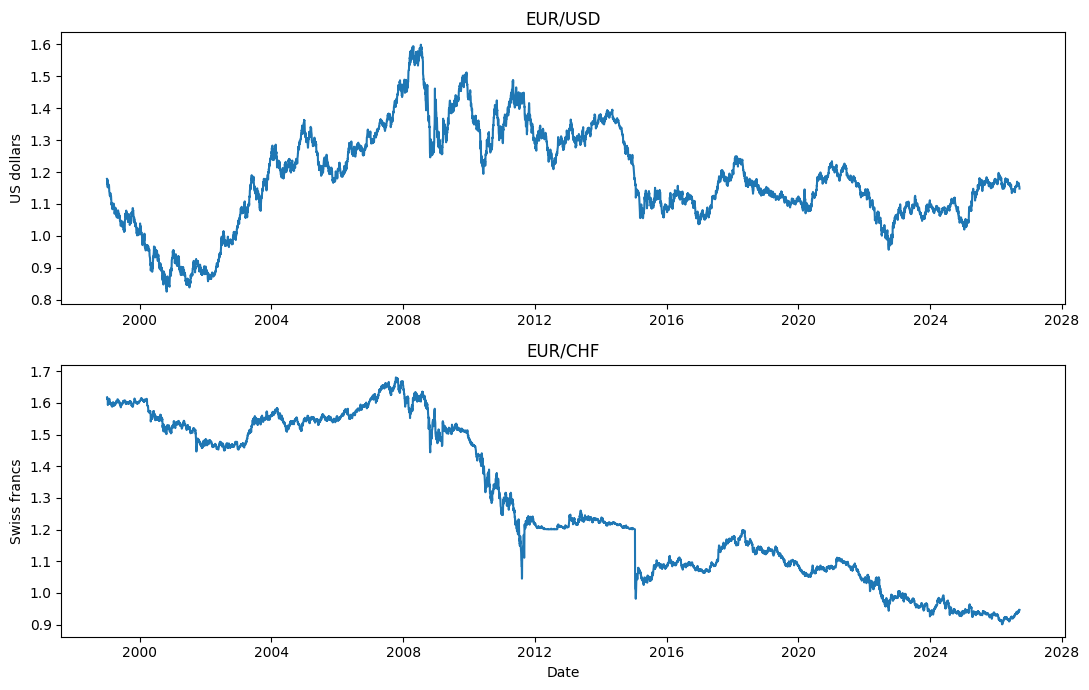

In [ ]:
# Your code here
fig , axes = plt.subplots(2,1, figsize=(11, 7))
axes[0].plot(df4["Date"], df4["USD"])
axes[0].set_title("EUR/USD")
axes[0].set_ylabel("US dollars")

axes[1].plot(df4["Date"], df4["CHF"])
axes[1].set_title("EUR/CHF")
axes[1].set_ylabel("Swiss francs")
axes[1].set_xlabel("Date")
plt.tight_layout()
#plt.legend()

plt.show()



## 5.3 Change by starting year

Make a bar chart from your table in 4.2, showing `usd_change` for each starting year. Colour bars below zero differently from those above.

This makes the start-date problem visible.

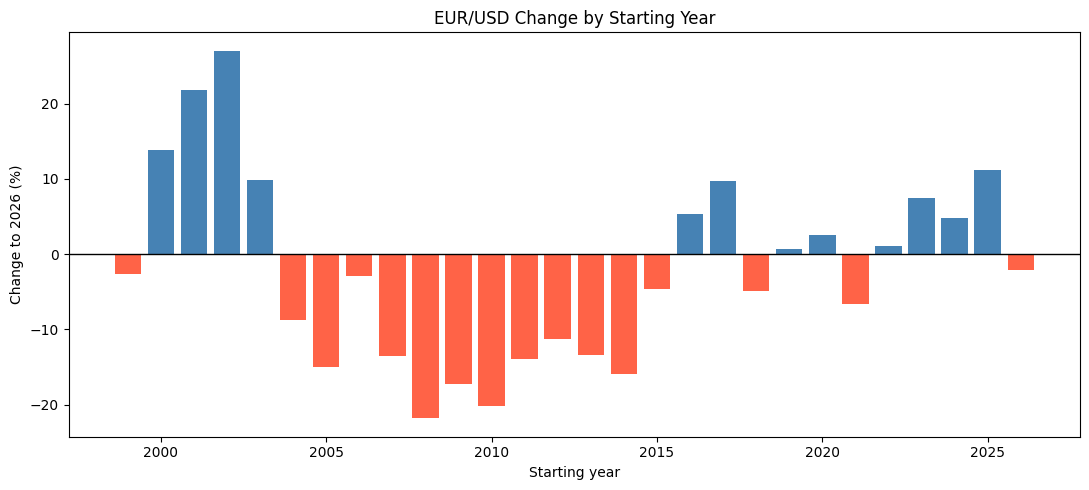

In [ ]:
# Your code here

# Different colours for falls and rises
colors = [
    "tomato" if x < 0 else "steelblue"
    for x in change_table["usd_change"]
]

plt.figure(figsize=(11, 5))

plt.bar(
    change_table.index,
    change_table["usd_change"],
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("EUR/USD Change by Starting Year")
plt.xlabel("Starting year")
plt.ylabel("Change to 2026 (%)")

plt.tight_layout()
plt.show()


## 5.4 How big are daily changes?

Draw a histogram of `usd_change` with 100 bins. Add `edgecolor='white'`.

What shape is it, and where are the extreme days?

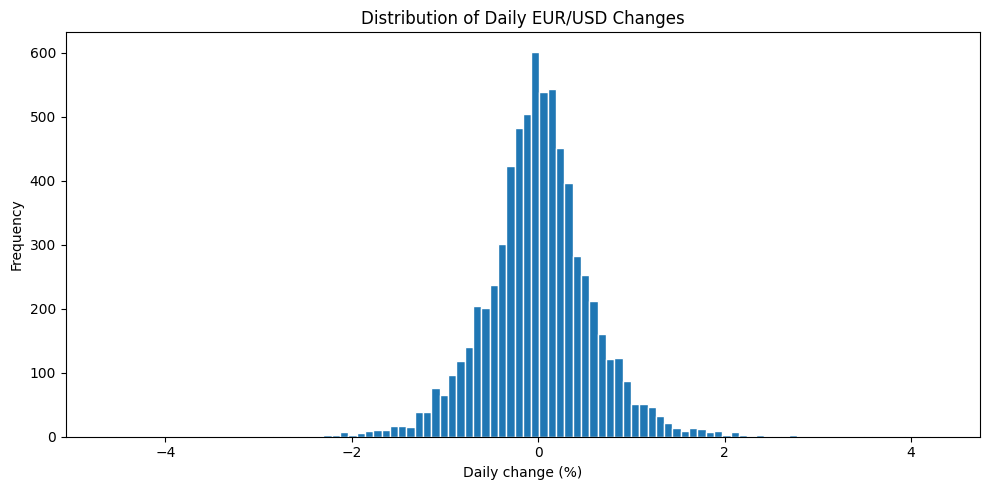

In [ ]:
# Your code here

plt.figure(figsize=(10, 5))

plt.hist(
    df4["usd_change"].dropna(),
    bins=100,
    edgecolor="white"
)

plt.title("Distribution of Daily EUR/USD Changes")
plt.xlabel("Daily change (%)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5.5 How much does each currency move each year?

Group by `year`, take the standard deviation of both change columns, and draw them as a bar chart with two bars per year.

Hint: `.plot(kind='bar')` on the grouped result does this in one line.

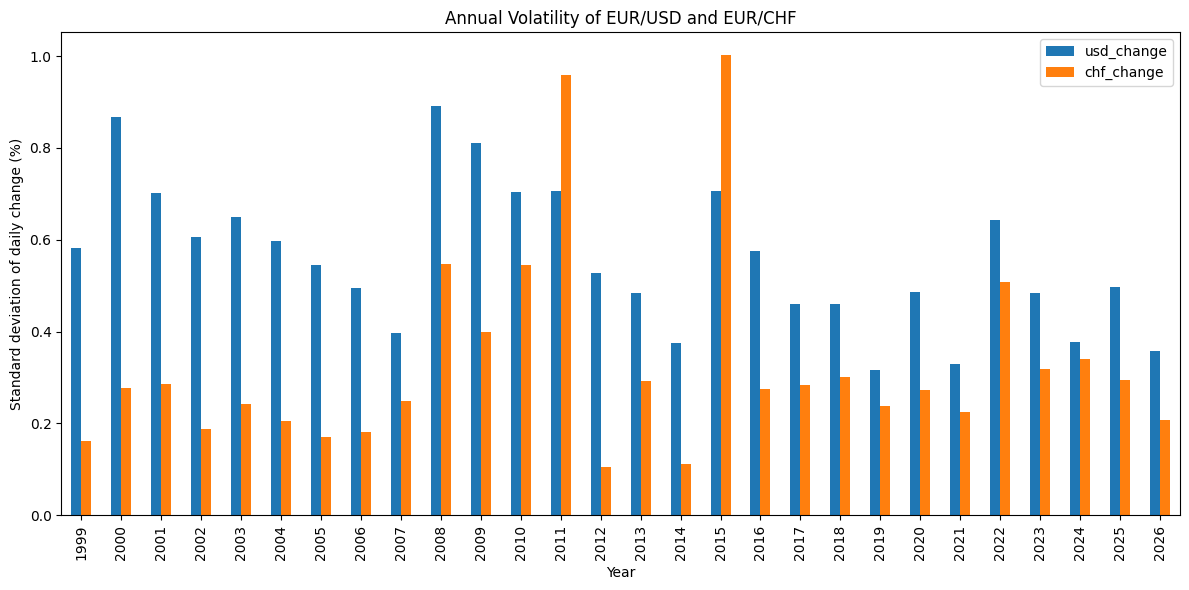

In [ ]:
# Your code here
movement_by_year = (
    df4.groupby("year")[["usd_change", "chf_change"]]
       .std()
)

movement_by_year.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Annual Volatility of EUR/USD and EUR/CHF")
plt.xlabel("Year")
plt.ylabel("Standard deviation of daily change (%)")

plt.tight_layout()
plt.show()

## 5.6 Do they move together?

Scatter `usd_change` against `chf_change`. Use `alpha=0.3` so overlapping points stay visible.

Does the picture match the correlation you calculated in 4.5?

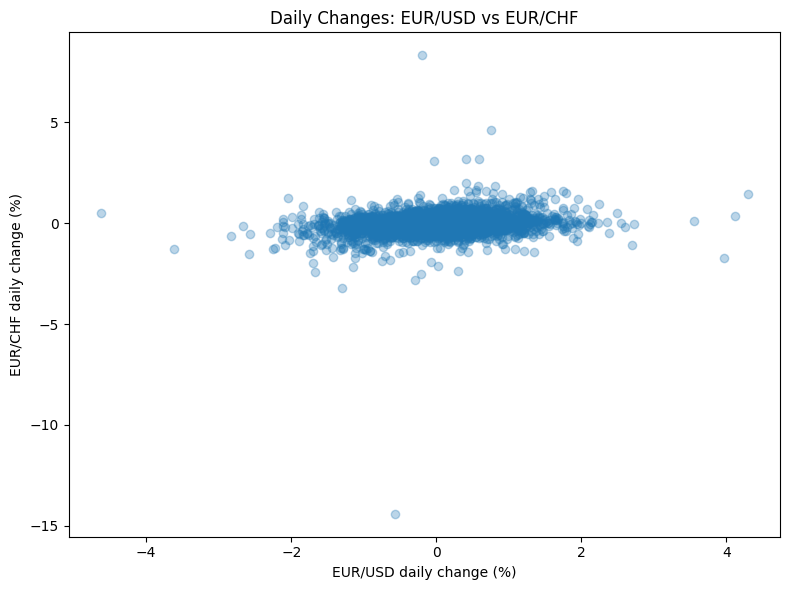

In [ ]:
# Your code here
plt.figure(figsize=(8, 6))

plt.scatter(
    df4["usd_change"],
    df4["chf_change"],
    alpha=0.3
)

plt.title("Daily Changes: EUR/USD vs EUR/CHF")
plt.xlabel("EUR/USD daily change (%)")
plt.ylabel("EUR/CHF daily change (%)")

plt.tight_layout()
plt.show()

## 5.7 Save your results

Save two things to an Excel file called `euro_analysis.xlsx`:

- a sheet called `Yearly` with the average rate per year
- a sheet called `Start Years` with your table from 4.2

Use `pd.ExcelWriter` inside a `with` block.

In [ ]:
# Your code here
yearly = (
    df4.groupby("year")[["USD", "CHF"]]
       .mean()
       .round(4)
)

with pd.ExcelWriter("euro_analysis.xlsx") as writer:
    yearly.to_excel(writer, sheet_name="Yearly")
    change_table.to_excel(writer, sheet_name="Start_Years")

print("euro_analysis.xlsx saved successfully.")

euro_analysis.xlsx saved successfully.


---
## Finished?

Write a short summary — about 150 words — for someone who will not read this
notebook. Include:

- the claim you tested
- your answer for each currency
- the one table or chart that convinced you
- the date range you used

Then add one sentence on what this data **cannot** tell you. It is a daily exchange
rate and nothing else: it does not say why the euro moved, and it does not say what
happens next.